In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ruspini.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   #       75 non-null     int64
 1   X       75 non-null     int64
 2   Y       75 non-null     int64
 3   CLASS   75 non-null     int64
dtypes: int64(4)
memory usage: 2.5 KB


In [3]:
df.head()

,#,X,Y,CLASS
0,1,4,53,1
1,2,5,63,1
2,3,10,59,1
3,4,9,77,1
4,5,13,49,1


In [4]:
# 2. Siapkan data
X = df[['X', 'Y']].values
y_true = df['CLASS'].values

In [5]:
# Inisialisasi list untuk menyimpan hasil
variances = []
error_ratios = []
n_experiments = 6
n_clusters = 4 


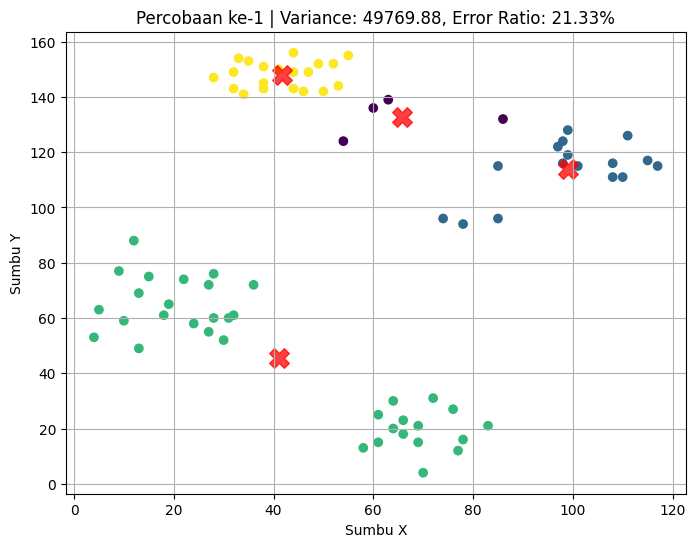

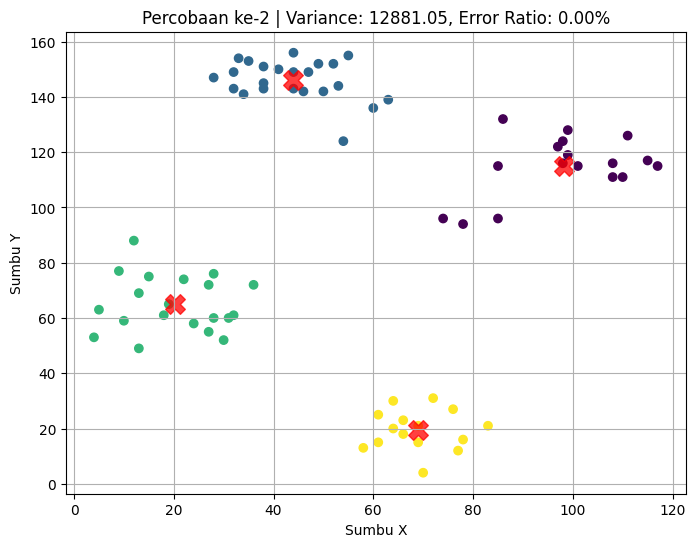

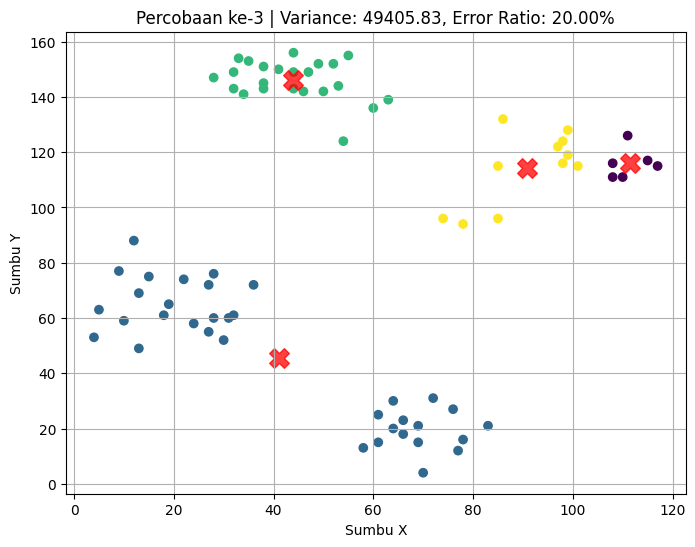

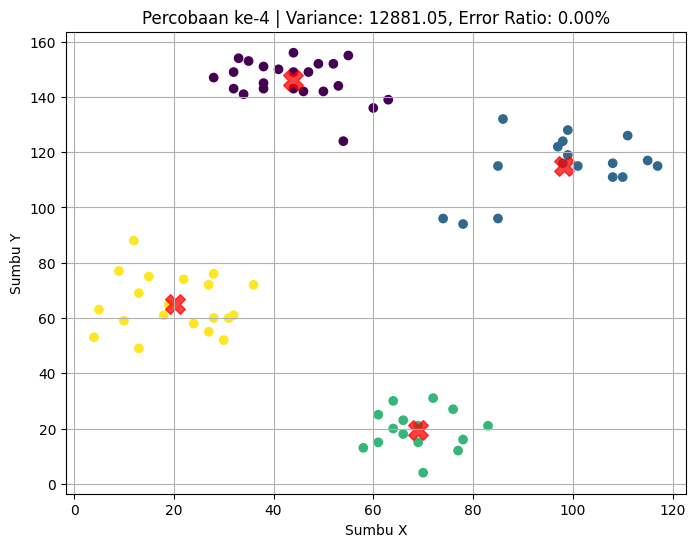

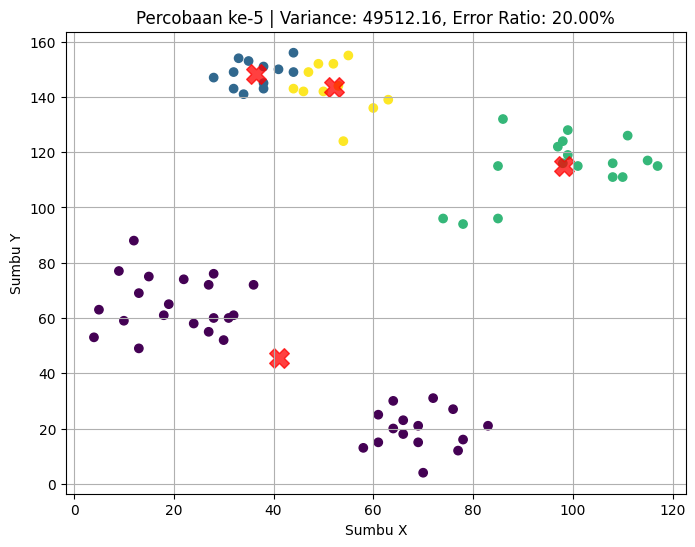

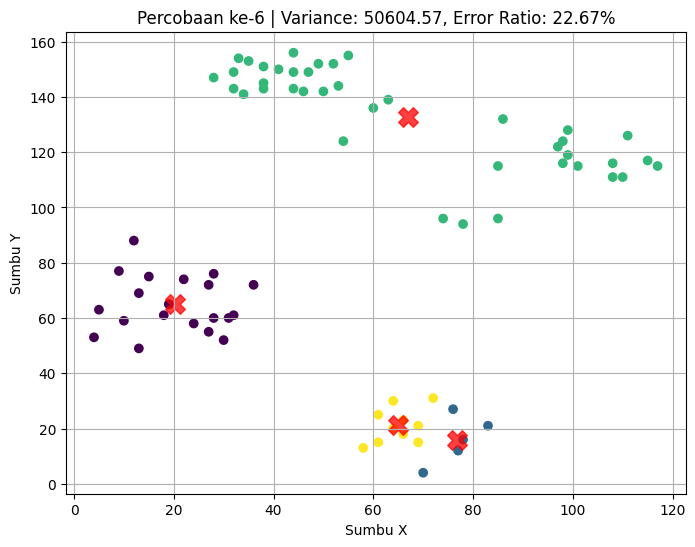

In [6]:
# 3. Lakukan percobaan sebanyak 6 kali
for i in range(n_experiments):
    # DIUBAH: init='random' dan n_init=1 untuk hasil yang lebih bervariasi
    kmeans = KMeans(n_clusters=n_clusters, init='random', n_init=1, random_state=i)
    y_pred = kmeans.fit_predict(X)
    
    # --- Perhitungan Error Ratio ---
    labels = np.zeros_like(y_pred)
    for k in range(n_clusters):
        mask = (y_pred == k)
        if np.any(mask): # Pastikan cluster tidak kosong
            labels[mask] = mode(y_true[mask], keepdims=True)[0]
    
    accuracy = accuracy_score(y_true, labels)
    error_ratio = 1 - accuracy
    error_ratios.append(error_ratio)
    # --------------------------------

    # Hitung dan simpan variance (inertia)
    variance = kmeans.inertia_
    variances.append(variance)
    
    # --- Visualisasi untuk Lokal ---
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', marker='o')
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
    plt.title(f'Percobaan ke-{i+1} | Variance: {variance:.2f}, Error Ratio: {error_ratio:.2%}')
    plt.xlabel('Sumbu X')
    plt.ylabel('Sumbu Y')
    plt.grid(True)
    plt.show() 
    # ------------------------------------

In [ ]:
print("Variances:", variances)
print("Error Ratios:", error_ratios)

Variances: [49769.88214285714, 12881.051236146634, 49405.8306606437, 12881.051236146634, 49512.16213394448, 50604.575]
Error Ratios: [0.21333333333333337, 0.0, 0.19999999999999996, 0.0, 0.19999999999999996, 0.22666666666666668]


In [8]:
# 4. Tampilkan ringkasan hasil akhir
average_variance = np.mean(variances)
average_error_ratio = np.mean(error_ratios)
print(f'Rata-rata Variance: {average_variance:.2f}')
print(f'Rata-rata Error Ratio: {average_error_ratio:.2%}')

Rata-rata Variance: 37509.09
Rata-rata Error Ratio: 14.00%
